## 2.3.1. Импорты, seed и среда

In [1]:
!pip install datasets transformers scikit-learn matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\korobochka_sahara\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 6)
pd.set_option("display.max_colwidth", 140)

C:\Users\korobochka_sahara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cpu
CUDA available: False


## 2.3.2. Данные и первичный анализ

In [4]:
# Выбран датасет emotion. У него уже есть train / validation / test, поэтому дополнительно делать split не требуется.

dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
split_sizes = {split: len(dataset[split]) for split in dataset.keys()}
split_sizes

{'train': 16000, 'validation': 2000, 'test': 2000}

In [6]:
label_feature = dataset["train"].features["label"]
label_names = label_feature.names
num_labels = len(label_names)

print("Количество классов:", num_labels)
print("Классы:", label_names)

Количество классов: 6
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [7]:
train_df = dataset["train"].to_pandas()

print("Примеры из train:")
display(train_df.sample(5, random_state=SEED))

Примеры из train:


,text,label
8756,ive made it through a week i just feel beaten down,0
4660,i feel this strategy is worthwhile,1
6095,i feel so worthless and weak what does he have to say that s what i want to find out,0
304,i feel clever nov,1
8241,im moved in ive been feeling kind of gloomy,0


In [8]:
print("Краткое пояснение задачи:")
print(
    "Нужно классифицировать текст по одной из эмоций: "
    + ", ".join(label_names)
    + "."
)

Краткое пояснение задачи:
Нужно классифицировать текст по одной из эмоций: sadness, joy, love, anger, fear, surprise.


## 2.3.3. Токенизация

In [9]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [10]:
token_examples = dataset["train"].select(range(5))

for i in range(len(token_examples)):
    text = token_examples[i]["text"]
    label_id = token_examples[i]["label"]
    encoded = tokenizer(text, truncation=True)

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    special_tokens = [tok for tok in tokens if tok in tokenizer.all_special_tokens]

    print("=" * 120)
    print(f"Example #{i + 1}")
    print("Text:", text)
    print("True label:", label_names[label_id])
    print("Tokens:", tokens)
    print("input_ids:", encoded["input_ids"])
    print("attention_mask:", encoded["attention_mask"])
    print("Special tokens:", special_tokens)

Example #1
Text: i didnt feel humiliated
True label: sadness
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Special tokens: ['[CLS]', '[SEP]']
Example #2
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
True label: sadness
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: ['[CLS]', '[SEP]']
Example #3
Text: im grabbing a minute to post i feel greedy wrong
True label: anger
Tokens: ['[CLS]', 'im', 'grabbing', 'a', 'm

In [11]:
# padding и truncation
sample_texts = [dataset["train"][i]["text"] for i in range(3)]

encoded_batch = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=12,
    return_tensors="pt",
)

print("input_ids shape:", tuple(encoded_batch["input_ids"].shape))
print("attention_mask shape:", tuple(encoded_batch["attention_mask"].shape))
print("\ninput_ids:")
print(encoded_batch["input_ids"])
print("\nattention_mask:")
print(encoded_batch["attention_mask"])

input_ids shape: (3, 12)
attention_mask shape: (3, 12)

input_ids:
tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
             0,     0],
        [  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
          9636,   102],
        [  101, 10047,  9775,  1037,  3371,  2000,  2695,  1045,  2514, 20505,
          3308,   102]])

attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


Краткий комментарий: Токенизатор преобразует текст в последовательность токенов и затем в `input_ids`.  
`attention_mask` показывает, какие позиции являются реальными токенами, а какие были добавлены паддингом.  
При `truncation=True` длинные тексты обрезаются до заданной длины, а `padding=True` выравнивает длины внутри батча.

## 2.3.4. Инференс готовой модели

In [12]:
# Для демонстрации инференса возьмём готовую модель sentiment-analysis, не обученную именно на emotion.

clf_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    tokenizer="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
)

inference_examples = [dataset["test"][i]["text"] for i in range(5)]
inference_true_labels = [label_names[dataset["test"][i]["label"]] for i in range(5)]
inference_preds = clf_pipe(inference_examples)

inference_df = pd.DataFrame(
    {
        "text": inference_examples,
        "true_emotion_label": inference_true_labels,
        "pretrained_model_prediction": [x["label"] for x in inference_preds],
        "score": [round(float(x["score"]), 4) for x in inference_preds],
    }
)

display(inference_df)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3623.17it/s]


,text,true_emotion_label,pretrained_model_prediction,score
0,im feeling rather rotten so im not very ambitious right now,sadness,NEGATIVE,0.9998
1,im updating my blog because i feel shitty,sadness,NEGATIVE,0.9995
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,POSITIVE,0.9993
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,POSITIVE,0.9868
4,i was feeling a little vain when i did this one,sadness,NEGATIVE,0.9996


Краткое пояснение: готовая pretrained-модель для sentiment analysis полезна как быстрый baseline для инференса, но она обучена на другой постановке (позитив / негатив), а не на многоклассовой задаче эмоций.  
Поэтому для датасета `emotion` она подходит лишь частично, и нужен fine-tuning на целевой задаче.

## 2.3.5. Fine-tuning для классификации текста

In [13]:
# Конфигурация эксперимента
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
NUM_EPOCHS = 2
WEIGHT_DECAY = 0.01

print(
    {
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "learning_rate": LEARNING_RATE,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "seed": SEED,
    }
)

{'model_name': 'distilbert-base-uncased', 'max_length': 128, 'learning_rate': 2e-05, 'train_batch_size': 16, 'eval_batch_size': 32, 'num_epochs': 2, 'weight_decay': 0.01, 'seed': 42}


In [14]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = dataset.map(tokenize_batch, batched=True)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [15]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
).to(device)

model.config

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3006.17it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.5.0",
  "vocab_size": 30522
}

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [38]:
training_args = TrainingArguments(
    output_dir="bert_emotion_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    report_to="none",
    save_total_limit=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [18]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.493384,0.184505,0.929500,0.899613
2,0.151646,0.148324,0.940000,0.914434


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.322514892578125, metrics={'train_runtime': 3140.274, 'train_samples_per_second': 10.19, 'train_steps_per_second': 0.637, 'total_flos': 389287358125632.0, 'train_loss': 0.322514892578125, 'epoch': 2.0})

In [27]:
validation_metrics = trainer.predict(tokenized_dataset["validation"])
validation_metrics

PredictionOutput(predictions=array([[ 5.875335  , -1.2826871 , -1.4061267 , -1.5659025 , -1.5548599 ,
        -2.2473307 ],
       [ 6.0200233 , -1.2864519 , -2.0239334 , -1.4002391 , -1.3221169 ,
        -2.1511705 ],
       [-1.9843273 ,  2.6565976 ,  3.562243  , -2.0172503 , -2.7225924 ,
        -2.5023108 ],
       ...,
       [-1.7759609 ,  6.1396284 , -0.78526974, -1.7498848 , -2.2355528 ,
        -1.3497185 ],
       [-2.3850467 ,  3.8294878 ,  2.984416  , -2.1923678 , -2.843423  ,
        -2.3163028 ],
       [-1.8869796 ,  5.9857936 , -0.79513156, -2.1084607 , -2.262155  ,
        -0.7284028 ]], shape=(2000, 6), dtype=float32), label_ids=array([0, 0, 2, ..., 1, 1, 1], shape=(2000,)), metrics={'test_loss': 0.14832431077957153, 'test_accuracy': 0.94, 'test_f1_macro': 0.914433696779926, 'test_runtime': 47.2573, 'test_samples_per_second': 42.322, 'test_steps_per_second': 1.333})

Лучший вариант выбирается по validation через `load_best_model_at_end=True` и  
`metric_for_best_model="f1_macro"`. После этого один раз проводится финальная оценка на test.

In [28]:
test_metrics = trainer.predict(tokenized_dataset["test"])
test_metrics

PredictionOutput(predictions=array([[ 5.9154477 , -1.1851315 , -1.9381988 , -0.90663713, -1.8249191 ,
        -2.1747482 ],
       [ 5.9933434 , -1.4172142 , -1.785492  , -1.2553823 , -1.5875871 ,
        -2.1901824 ],
       [ 5.989136  , -1.3902617 , -1.7493453 , -1.5124454 , -1.3968234 ,
        -2.1718774 ],
       ...,
       [-1.8135931 ,  6.2002215 , -0.82677615, -1.8903446 , -2.373002  ,
        -1.0895665 ],
       [-1.4955895 ,  5.93323   , -1.104904  , -1.9418676 , -1.7210525 ,
        -1.1206644 ],
       [-1.4160831 , -2.0727053 , -1.9919647 , -2.0521758 ,  2.8072526 ,
         2.9366205 ]], shape=(2000, 6), dtype=float32), label_ids=array([0, 0, 0, ..., 1, 1, 4], shape=(2000,)), metrics={'test_loss': 0.18198855221271515, 'test_accuracy': 0.9245, 'test_f1_macro': 0.8767565576288069, 'test_runtime': 45.35, 'test_samples_per_second': 44.101, 'test_steps_per_second': 1.389})

## 2.3.6. Оценка качества и краткий анализ ошибок

In [ ]:
test_predictions = trainer.predict(tokenized_dataset["test"])
test_logits = test_predictions.predictions
test_true = test_predictions.label_ids
test_pred = np.argmax(test_logits, axis=1)
test_conf = torch.softmax(torch.tensor(test_logits), dim=1).max(dim=1).values.numpy()

final_accuracy = accuracy_score(test_true, test_pred)
final_f1_macro = f1_score(test_true, test_pred, average="macro")

print(f"Test accuracy  : {final_accuracy:.4f}")
print(f"Test f1_macro  : {final_f1_macro:.4f}")

Test accuracy  : 0.9245
Test f1_macro  : 0.8768


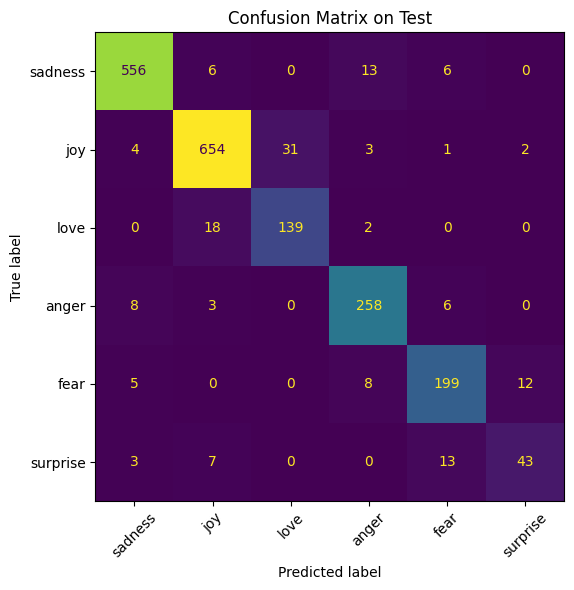

Saved: C:\Users\korobochka_sahara\dpo\dpo-ai\homeworks\HW13\artifacts\confusion_matrix.png


In [32]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()

cm_path = Path("artifacts/confusion_matrix.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", cm_path.resolve())

In [35]:
sample_predictions_df = pd.DataFrame(
    {
        "text": dataset["test"]["text"],
        "true_label": [label_names[i] for i in test_true],
        "pred_label": [label_names[i] for i in test_pred],
        "confidence": np.round(test_conf, 4),
    }
)

sample_csv_path = Path("artifacts/sample_predictions.csv")
sample_predictions_df.to_csv(sample_csv_path, index=False)

print("Saved:", sample_csv_path.resolve())
display(sample_predictions_df.head(10))

Saved: C:\Users\korobochka_sahara\dpo\dpo-ai\homeworks\HW13\artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9970
1,im updating my blog because i feel shitty,sadness,sadness,0.9975
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9975
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9972
4,i was feeling a little vain when i did this one,sadness,sadness,0.9974
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9943
6,i felt anger when at the end of a telephone call,anger,anger,0.9930
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,joy,joy,0.9227
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9969
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on ...,anger,anger,0.9945


In [36]:
print("Примеры предсказаний модели (10 строк):")
display(
    sample_predictions_df.sample(10, random_state=SEED).reset_index(drop=True)
)

Примеры предсказаний модели (10 строк):


,text,true_label,pred_label,confidence
0,i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter between us luckily fo...,sadness,sadness,0.9963
1,i could feel his breath on me and smell the sweet scent of him,joy,love,0.8915
2,i just want to feel loved by you,love,love,0.9741
3,i have felt the need to write out my sometimes anxious feelings impatient thoughts lists of things that still should could be done befor...,anger,fear,0.8275
4,at a party i met a girl who drew me to her,anger,fear,0.6997
5,i feel this strange sort of liberation,surprise,fear,0.7725
6,i remember feeling thrilled to use my nursing skills relieved that i could have a few days out of the house and i remember that at first...,joy,joy,0.9970
7,i always feel sympathetic for those that do as well because life can be really hard on you sometimes when you do have alot of pride,love,love,0.9845
8,i feel a little stunned but can t imagine what the folks who were working in the studio up until this morning are feeling,surprise,surprise,0.9628
9,i feel slytherin is my house slytherin is for those who are smart enough to know how to get the job done and at any cost,joy,joy,0.9032


In [37]:
errors_df = sample_predictions_df[sample_predictions_df["true_label"] != sample_predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Количество ошибок на test: {len(errors_df)}")
display(errors_df.head(10))

Количество ошибок на test: 151


,text,true_label,pred_label,confidence
0,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9972
1,i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible for her your boss tre...,anger,sadness,0.9969
2,i feel very saddened that the king whom i once quite respected as far as monarchs go was ineffectual at best,joy,sadness,0.9962
3,i feel affirmed gracious sensuous and will have less self doubt when a href http generations,love,joy,0.9936
4,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep...,fear,sadness,0.9928
5,i felt a stronger wish to be free from self cherishing through my refuge practice and a return to the feeling of freedom and protection ...,sadness,joy,0.9928
6,i don t feel betrayed coz the backstabber had no grounds for their accusation but i m just amazed at some people s ability to do such th...,surprise,sadness,0.9889
7,i was playing a sport in an advanced pe class and many of the people were not advanced,anger,joy,0.9852
8,i hate these feelings in my heart i hate that work stressed me out i hate that cornelius wont let me get my way im frustrated lord,sadness,anger,0.9842
9,i guess no matter how much i think im feeling ok im as nervous as hell on the inside about the scan revealing something i dont want to k...,joy,fear,0.9838


### Краткий анализ ошибок

- часть ошибок возникает между семантически близкими эмоциями, например `joy` и `love`, либо `anger` и `fear`;
- короткие и контекстно бедные тексты классифицировать труднее, потому что явных маркеров эмоции мало;
- модель иногда путается в текстах со смешанной эмоциональной окраской, где есть несколько сигналов одновременно;
- высокий `confidence` при ошибке обычно означает, что пример для модели похож на частый паттерн другого класса.

Именно поэтому матрица ошибок и просмотр конкретных misclassified-примеров полезны даже при неплохих агрегированных метриках.